# KORELASI GANDA

DATA


Bulan,Harga Beras (Rp) (Y),Suhu Udara (°C) (X1),Produksi Padi (Ton) (X2)
2018-01-01 00:00:00,12276.000000,25.130000,2783961.000000
2018-02-01 00:00:00,12414.000000,25.360000,5738544.000000
2018-03-01 00:00:00,12299.000000,25.560000,9678183.000000
2018-04-01 00:00:00,12035.000000,26.000000,7603155.000000
2018-05-01 00:00:00,11943.000000,25.460000,4901169.000000
2018-06-01 00:00:00,11907.260000,24.440000,4490438.000000
2018-07-01 00:00:00,11936.000000,22.750000,5434002.000000
2018-08-01 00:00:00,11899.000000,22.930000,5372660.000000
2018-09-01 00:00:00,11900.000000,24.750000,5184049.000000
2018-10-01 00:00:00,11926.210000,26.240000,3324970.000000




HASIL PERHITUNGAN


Perhitungan,Nilai
Jumlah Data (n),96
Korelasi Y dengan X1,0.176500
Korelasi Y dengan X2,-0.004200
Korelasi X1 dengan X2,-0.011800
Nilai R,0.176500
Nilai k,2
F Hitung,1.495300
Taraf Signifikansi,0.050000
df1,2
df2,93



Hasil berhasil disimpan.


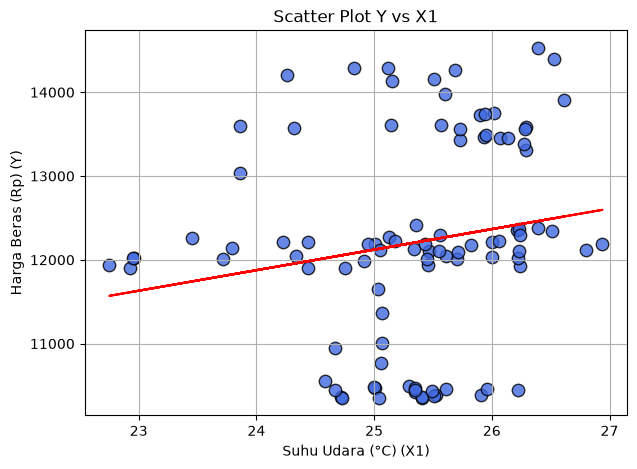

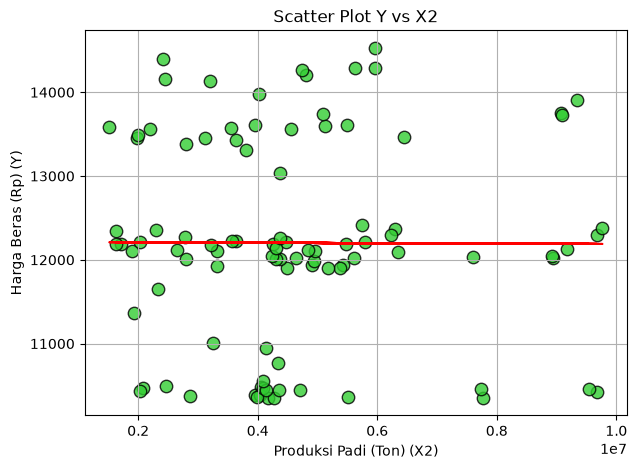

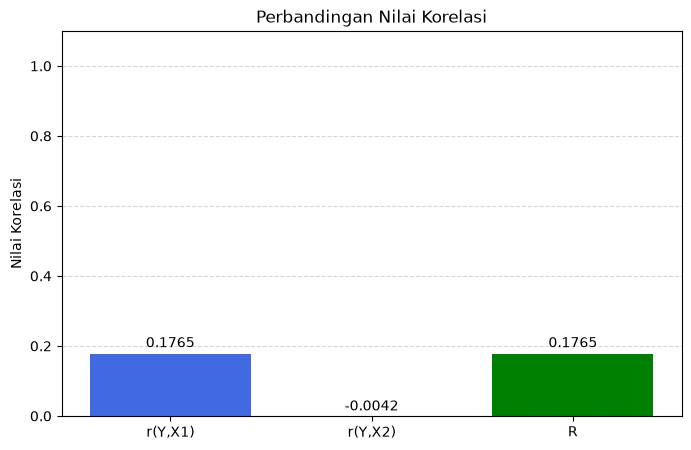



PENGAMBILAN KEPUTUSAN
Jumlah Data (n)          : 96
Korelasi Y dengan X1     : 0.1765
Korelasi Y dengan X2     : -0.0042
Korelasi X1 dengan X2    : -0.0118
Nilai R                  : 0.1765
F Hitung                 : 1.4953
F Tabel                  : 3.0943
Hubungan                 : Sangat Rendah
Keputusan                : H0 Diterima (Tidak Signifikan)


In [2]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import f
from sklearn.linear_model import LinearRegression
from IPython.display import display

# ==========================================================
# MEMBACA FILE EXCEL
# ==========================================================
file_excel = "Data.xlsx"      # Ganti sesuai nama file
sheet = "Data"

df = pd.read_excel(file_excel, sheet_name=sheet)

print("="*60)
print("DATA")
print("="*60)
display(df.style.hide(axis="index"))

# ==========================================================
# MENGAMBIL VARIABEL
# ==========================================================
Y = df.iloc[:,1]
X1 = df.iloc[:,2]
X2 = df.iloc[:,3]

# ==========================================================
# JUMLAH DATA
# ==========================================================
n = len(df)

# ==========================================================
# KORELASI PRODUCT MOMENT
# ==========================================================
r_yx1, p1 = pearsonr(Y, X1)
r_yx2, p2 = pearsonr(Y, X2)
r_x1x2, p3 = pearsonr(X1, X2)

# ==========================================================
# KORELASI GANDA
# ==========================================================
R = np.sqrt(
    (
        (r_yx1**2)
        +(r_yx2**2)
        -2*r_yx1*r_yx2*r_x1x2
    )
    /
    (1-r_x1x2**2)
)

# ==========================================================
# UJI F
# ==========================================================
k = 2
alpha = 0.05

F_hitung = (R**2/k)/((1-R**2)/(n-k-1))

df1 = k
df2 = n-k-1

F_tabel = f.ppf(1-alpha, df1, df2)

# ==========================================================
# MENENTUKAN HUBUNGAN
# ==========================================================
def hubungan(r):

    r = abs(r)

    if r < 0.20:
        return "Sangat Rendah"

    elif r < 0.40:
        return "Rendah"

    elif r < 0.60:
        return "Sedang"

    elif r < 0.80:
        return "Kuat"

    else:
        return "Sangat Kuat"

# ==========================================================
# KESIMPULAN
# ==========================================================
if F_hitung > F_tabel:
    keputusan = "H0 Ditolak (Hubungan Signifikan)"
else:
    keputusan = "H0 Diterima (Tidak Signifikan)"

# ==========================================================
# TABEL HASIL
# ==========================================================
hasil = pd.DataFrame({

    "Perhitungan":[
        "Jumlah Data (n)",
        "Korelasi Y dengan X1",
        "Korelasi Y dengan X2",
        "Korelasi X1 dengan X2",
        "Nilai R",
        "Nilai k",
        "F Hitung",
        "Taraf Signifikansi",
        "df1",
        "df2",
        "F Tabel",
        "Hubungan Nilai R",
        "Kesimpulan"
    ],

    "Nilai":[
        n,
        round(r_yx1,4),
        round(r_yx2,4),
        round(r_x1x2,4),
        round(R,4),
        k,
        round(F_hitung,4),
        alpha,
        df1,
        df2,
        round(F_tabel,4),
        hubungan(R),
        keputusan
    ]

})

print("\n")
print("="*60)
print("HASIL PERHITUNGAN")
print("="*60)
display(hasil.style.hide(axis="index"))

# ==========================================================
# SIMPAN HASIL KE EXCEL
# ==========================================================
with pd.ExcelWriter("Hasil Korelasi Ganda.xlsx") as writer:

    df.to_excel(writer,
                sheet_name="Data",
                index=False)

    hasil.to_excel(writer,
                   sheet_name="Perhitungan",
                   index=False)

print("\nHasil berhasil disimpan.")

# ==========================================================
# VISUALISASI 1
# SCATTER Y VS X1
# ==========================================================
plt.figure(figsize=(7,5))

plt.scatter(
    X1,
    Y,
    s=80,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

model=LinearRegression()

model.fit(np.array(X1).reshape(-1,1),Y)

plt.plot(X1,
         model.predict(np.array(X1).reshape(-1,1)),
         color="red")

plt.xlabel(X1.name)

plt.ylabel(Y.name)

plt.title("Scatter Plot Y vs X1")

plt.grid()

plt.show()

# ==========================================================
# VISUALISASI 2
# SCATTER Y VS X2
# ==========================================================
plt.figure(figsize=(7,5))

plt.scatter(
    X2,
    Y,
    s=80,
    color="limegreen",
    edgecolor="black",
    alpha=0.8
)

model=LinearRegression()

model.fit(np.array(X2).reshape(-1,1),Y)

plt.plot(X2,
         model.predict(np.array(X2).reshape(-1,1)),
         color="red")

plt.xlabel(X2.name)

plt.ylabel(Y.name)

plt.title("Scatter Plot Y vs X2")

plt.grid()

plt.show()

# ==========================================================
# VISUALISASI 3
# BAR CHART
# ==========================================================
plt.figure(figsize=(8,5))

nama = ["r(Y,X1)", "r(Y,X2)", "R"]

nilai = [r_yx1, r_yx2, R]

warna = ["royalblue","orange","green"]

bars = plt.bar(nama, nilai, color=warna)

plt.ylim(0,1.1)

plt.ylabel("Nilai Korelasi")

plt.title("Perbandingan Nilai Korelasi")

for bar in bars:

    tinggi = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        tinggi+0.02,
        f"{tinggi:.4f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# ==========================================================
# PENGAMBILAN KEPUTUSAN
# ==========================================================
print("\n")
print("="*60)
print("PENGAMBILAN KEPUTUSAN")
print("="*60)

print(f"Jumlah Data (n)          : {n}")
print(f"Korelasi Y dengan X1     : {r_yx1:.4f}")
print(f"Korelasi Y dengan X2     : {r_yx2:.4f}")
print(f"Korelasi X1 dengan X2    : {r_x1x2:.4f}")
print(f"Nilai R                  : {R:.4f}")
print(f"F Hitung                 : {F_hitung:.4f}")
print(f"F Tabel                  : {F_tabel:.4f}")
print(f"Hubungan                 : {hubungan(R)}")
print(f"Keputusan                : {keputusan}")

print("="*60)